<a href="https://colab.research.google.com/github/s-atwood/CmdKeeper/blob/main/Lab_6_Motion_of_mass_on_spring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing libraries

In [2]:
#6.0.1
import io  #io has the tools we need to "i"nput and "o"utput files.
import pandas as pd #pandas has tools to deal with tables of data (normally tables are called "DataFrames" in Python).
import numpy as np #np has mathematical tools we will need every week.
from google.colab import files #files allow us to upload our csv files into google Colab.
import matplotlib.pyplot as plt #our plotting tools

from scipy.optimize import curve_fit #our curve fitting tool


Task 1: Different masses at rest

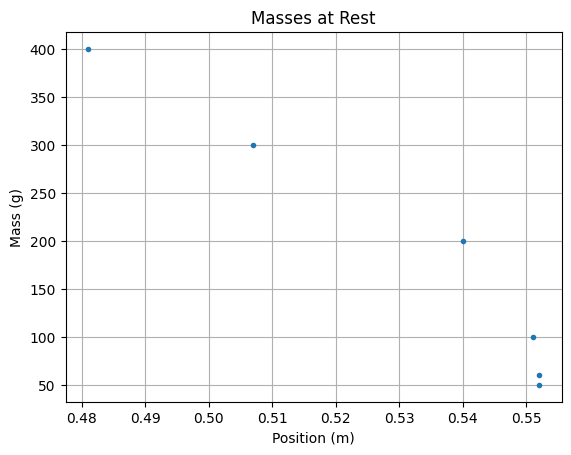

In [3]:
#6.1.1
#spring_mass= 72.5

mass_list=np.array([        400,  300,  200, 100, 60, 50 ])  #You need to fill in this list with the masses you have chosen to add to the spring.
position_at_rest=np.array([.481, .507, .540, .551, .552, .552])  #You should use the CBR to find the positions of the hook when the hook is at rest (make sure you record the masses and positions so they correspond with each other).

#mass_list=mass_list+spring_mass/2  #Does adding the half the weight of our spring make any difference to our calculations?

plt.grid()
plt.plot(position_at_rest, mass_list, '.')

plt.ylabel("Mass (g)")
plt.xlabel("Position (m)")
plt.title("Masses at Rest")
plt.show()


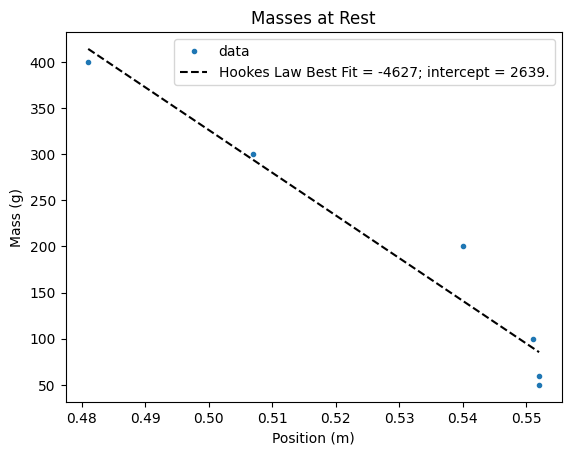

In [4]:
#6.1.2
Xvalues= position_at_rest   #You must explicity tell the computer what you want displayed on the X-axis.  Don't forget that you can limit your data by using [start:end]
Yvalues= mass_list    #Same for the Y-axis.


def model_Linear(x,m,b):  #We are using y=m x+b as our model
  return m*(x)+b

[m_opt, b_opt], pcov = curve_fit(model_Linear, Xvalues, Yvalues)#you need to figure out what you want as your Xvalues and Yvalues to complete this fit.


y_model = model_Linear(Xvalues, m_opt, b_opt)  #this uses the optimum slope and intercept that were just calculated to calculate y_model values our Linear Model

plt.plot(Xvalues,Yvalues, '.',   label="data")
plt.plot(Xvalues,y_model, '--k', label=f'Hookes Law Best Fit = {str(m_opt)[0:5]}; intercept = {str(b_opt)[0:5]}')
plt.ylabel("Mass (g)")
plt.xlabel("Position (m)")
plt.title("Masses at Rest")
plt.legend()
plt.show()

In [5]:
#6.1.3
k_at_rest=9.81/m_opt
print(k_at_rest)
x_0_at_rest=b_opt
print(x_0_at_rest)

-0.0021198868085745962
2639.944754101889


Task 2: Bouncing Mass

In [6]:
#6.2.1
uploaded = files.upload() #This command gets our data file into google colab's memory
dataframe = pd.read_csv(io.BytesIO(uploaded[next(iter(uploaded))]))# This now moves the data we uploaded into a "dataframe" which we can then manipulate.

print(dataframe[0:2])

Saving Lab6 Bouncing Export 1(in).csv to Lab6 Bouncing Export 1(in).csv
   Data Set 1:Time(s)  Data Set 1:Position(m)  Data Set 1:Velocity(m/s)  \
0                0.00                0.479303                  0.003460   
1                0.05                0.479407                  0.005129   

   Data Set 1:Acceleration(m/sÂ²)  Data Set 2:Time(s)  Data Set 2:Position(m)  \
0                        0.032852                0.00                0.507459   
1                        0.029532                0.05                0.507961   

   Data Set 2:Velocity(m/s)  Data Set 2:Acceleration(m/sÂ²)  \
0                  0.010407                        0.007444   
1                  0.010903                       -0.001722   

   Data Set 3:Time(s)  Data Set 3:Position(m)  ...  Data Set 5:Velocity(m/s)  \
0                0.00                0.537963  ...                 -0.001674   
1                0.05                0.537185  ...                 -0.001182   

   Data Set 5:Acceleration(

In [8]:
#6.2.2
#These abbreviations will help your code be easier to read.
i=1
header='Bouncing Data Set '

time=header+str(i)+':Time(s)' #This should match the first column header in the previous cell's output.  This is the version you get if you do not run the data directly to your computer.
pos=header+str(i)+':Position(m)'
vel=header+str(i)+':Velocity(m/s)'
acc=header+str(i)+':Acceleration(m/s²)'


df=dataframe[[time,pos,vel]].dropna()  #this limits our data to just one run and removes any annoying NaN values that might be hiding at the end of our data.
#So "dataframe" has all the data from the csv file, "df" only holds the data from the single run we are looking at now.

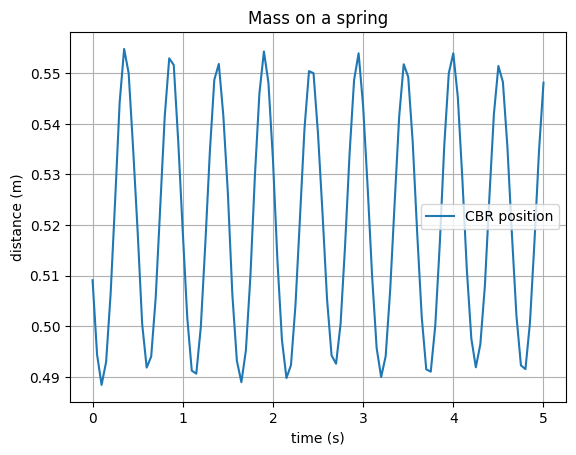

In [9]:
#6.2.3
bouncing_mass = mass_list #Include the mass of the hook but not the spring here.

#According to an old physics paper we might want to include 1/3 of the mass of the spring if the object is bouncing.  But we should compare results to see if this actually improves our data quality...
#bouncing_mass=bouncing_mass+spring_mass/3


plt.plot(df[time],df[pos], '-', label="CBR position") #this plots position vs time.  Not what we need but it is good to check that this matches what the labquest displayed.
plt.legend()
plt.grid()
plt.ylabel("distance (m)")
plt.xlabel("time (s)")
plt.title("Mass on a spring")
plt.show()


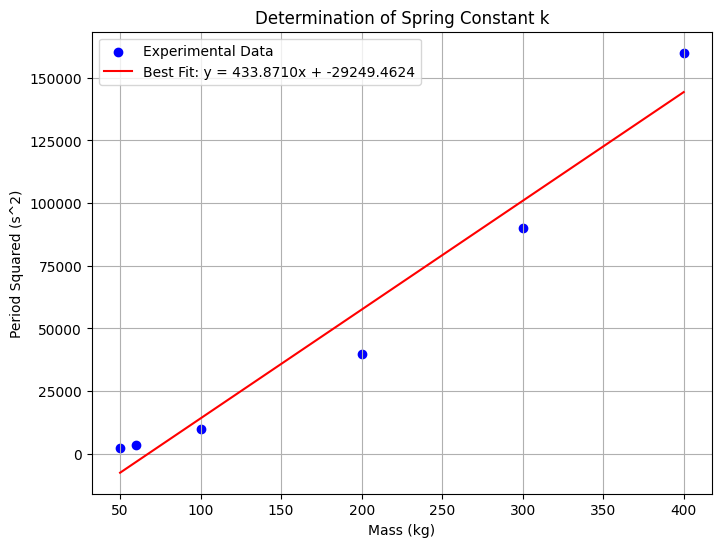

Calculated Spring Constant k = 0.09 N/m


In [10]:
#6.2.4
#space for the coder to make plots from the dataframe data

import numpy as np
import matplotlib.pyplot as plt

# 1. Define your data (Ensure period_list is calculated from your CBR data)
# bouncing_mass = mass_list
# period_list = [...] # Average time for one bounce for each mass

x = np.array(bouncing_mass)
y = np.array(mass_list)**2

# 2. Calculate the linear best fit (y = mx + b)
# slope is (4 * pi^2 / k)
slope, intercept = np.polyfit(x, y, 1)
y_fit = slope * x + intercept

# 3. Generate the Graph
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Experimental Data')
plt.plot(x, y_fit, color='red', label=f'Best Fit: y = {slope:.4f}x + {intercept:.4f}')

plt.xlabel("Mass (kg)")
plt.ylabel("Period Squared (s^2)")
plt.title("Determination of Spring Constant k")
plt.legend()
plt.grid(True)
plt.show()

# 4. Calculate k from the slope
k = (4 * np.pi**2) / slope
print(f"Calculated Spring Constant k = {k:.2f} N/m")

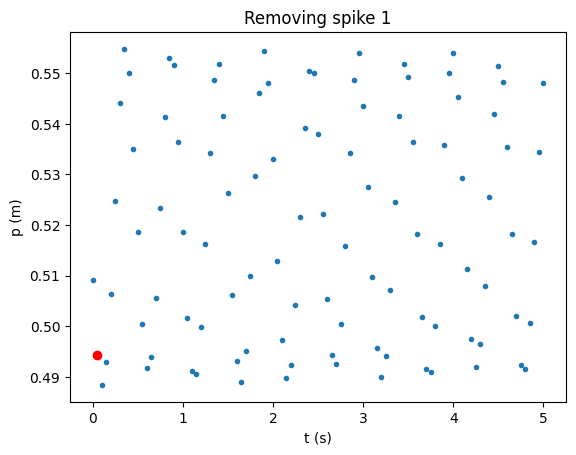

In [12]:
spike1start=1  #this value is probably incorrect.  The goal is to change this number until the bad portion of the data is highlighted in red in the plot.
spike1end=2   #this value is probably also incorrect.


spike1time=df[time][spike1start:spike1end]
spike1pos=df[pos][spike1start:spike1end]


plt.plot(df[time],df[pos],'.')  #this plots all of your data
plt.plot(spike1time,spike1pos,'ro')  #this is trying to highlight the bad portion in red.  Adjust spike1start and spike1end to highlight the correct region.

plt.ylabel("p (m)")
plt.xlabel("t (s)")
plt.title("Removing spike 1")
plt.show()

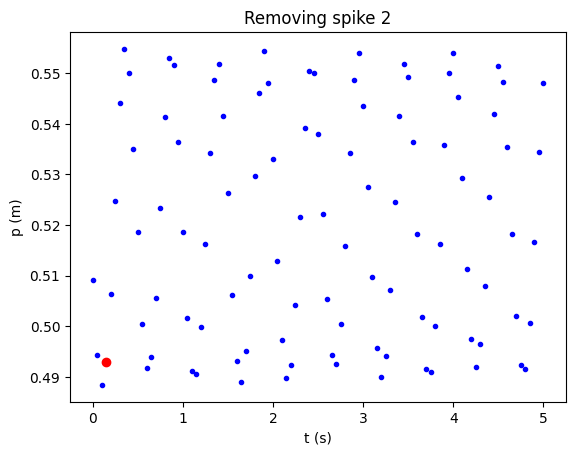

In [13]:
spike2start=3  #this value is probably incorrect.  The goal is to change this number until the bad portion of the data is highlighted in red in the plot.
spike2end=4   #this value is probably also incorrect.

spike2time=df[time][spike2start:spike2end]
spike2accel=df[pos][spike2start:spike2end]

plt.plot(df[time],df[pos],'b.')
plt.plot(spike2time,spike2accel,'ro')  #this is trying to highlight the bad portion in red.  Adjust spike2start and spike2end to highlight the region of bad data.

plt.ylabel("p (m)")
plt.xlabel("t (s)")
plt.title("Removing spike 2")

plt.show()

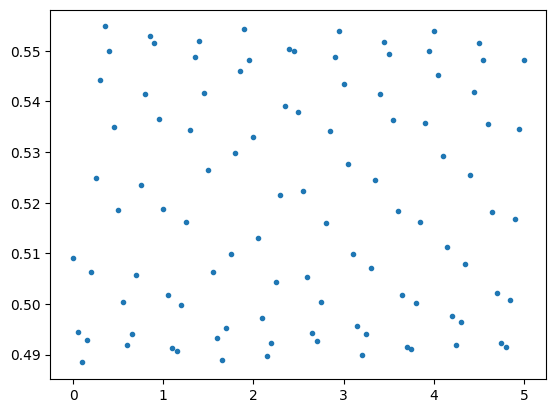

In [15]:
plt.plot(df[time],df[pos],'.')
#plt.title("position of the spring with bad data removed with mass of",mass_1,"grams")
plt.show()

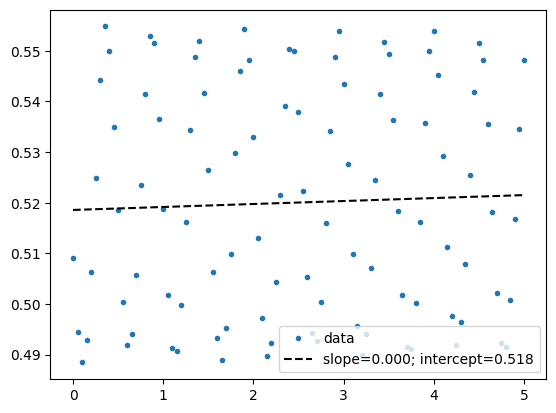

In [17]:
Xvalues=df[time]     #You must explicity tell the computer what you want displayed on the X-axis.  Don't forget that you can limit your data by using [start:end]
Yvalues=df[pos]     #Same for the Y-axis.


def model_Linear(x,m,b):  #We are using y=m x+b as our model
  return m*(x)+b

[m_opt, b_opt], pcov = curve_fit(model_Linear, Xvalues, Yvalues)#you need to figure out what you want as your Xvalues and Yvalues to complete this fit.


y_model = model_Linear(Xvalues, m_opt, b_opt)  #this uses the optimum slope and intercept that were just calculated to calculate y_model values our Linear Model

plt.plot(Xvalues,Yvalues, '.',   label="data")
plt.plot(Xvalues,y_model, '--k', label='slope='+str(m_opt)[0:5]+'; intercept='+str(b_opt)[0:5])

#plt.title("position of the spring with bad data removed with mass of",mass_1,"grams")
plt.legend()
plt.show()

In [ ]:
#6.2.5
k_bouncing=
print(k_bouncing)
x_0_at_rest=
print(x_0_at_rest)

In [ ]:
#6.2.6
#space for the researcher to compare uncertainties.


